In [1]:
 import os
print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
print(os.listdir('/kaggle/input/datasets'))

['riyakonde21']


In [3]:
print(os.listdir('/kaggle/input/datasets/riyakonde21/fashion-mnist'))

['fashion-mnist_test.csv', 'fashion-mnist_train.csv']


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

print("TensorFlow Version:", tf.__version__)

2026-03-02 16:56:24.425492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772470584.681895      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772470584.756794      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772470585.368679      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772470585.368742      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772470585.368745      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [5]:
dataset_path = "/kaggle/input/datasets/riyakonde21/fashion-mnist"

print("Files inside dataset:")
print(os.listdir(dataset_path))

Files inside dataset:
['fashion-mnist_test.csv', 'fashion-mnist_train.csv']


In [6]:
train_path = dataset_path + "/fashion-mnist_train.csv"
test_path  = dataset_path + "/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


In [7]:
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

In [8]:
 
# STEP 5: Normalize Pixel Values (0-255 → 0-1)
 
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
# reshape

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [10]:
print("Reshaped Train:", x_train.shape)

Reshaped Train: (60000, 28, 28, 1)


In [11]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


In [12]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-02 16:58:23.950391: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.7186 - loss: 0.7965 - val_accuracy: 0.8585 - val_loss: 0.3924
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8581 - loss: 0.3866 - val_accuracy: 0.8795 - val_loss: 0.3251
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8833 - loss: 0.3265 - val_accuracy: 0.8915 - val_loss: 0.3051
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.8910 - loss: 0.2909 - val_accuracy: 0.9042 - val_loss: 0.2698
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9059 - loss: 0.2597 - val_accuracy: 0.9038 - val_loss: 0.2612
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9084 - loss: 0.2483 - val_accuracy: 0.9075 - val_loss: 0.2496
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9172 - loss: 0.2256 - val_accuracy: 0.9075 - val_loss: 0.2487
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9219 - loss: 0.2105 - 

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\n==========================")
print("Test Accuracy:", test_acc)
print("==========================")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9155 - loss: 0.2285

Test Accuracy: 0.9190999865531921


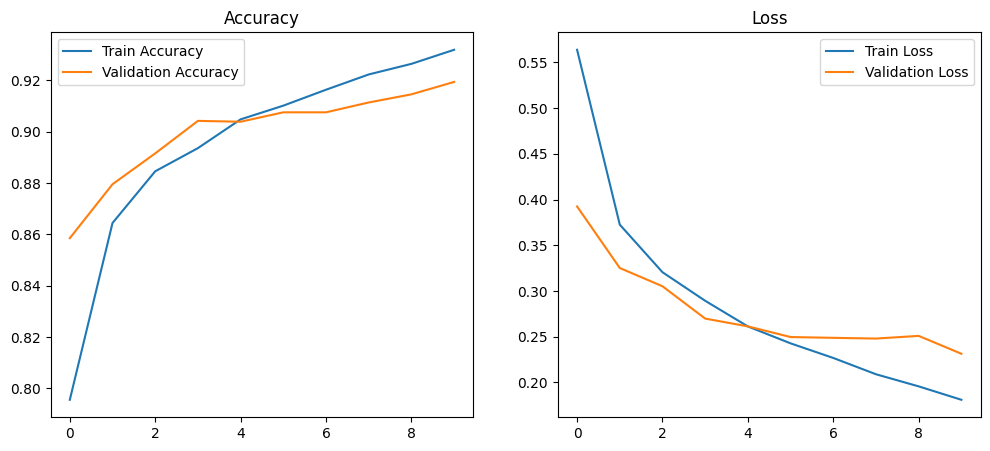

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [17]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


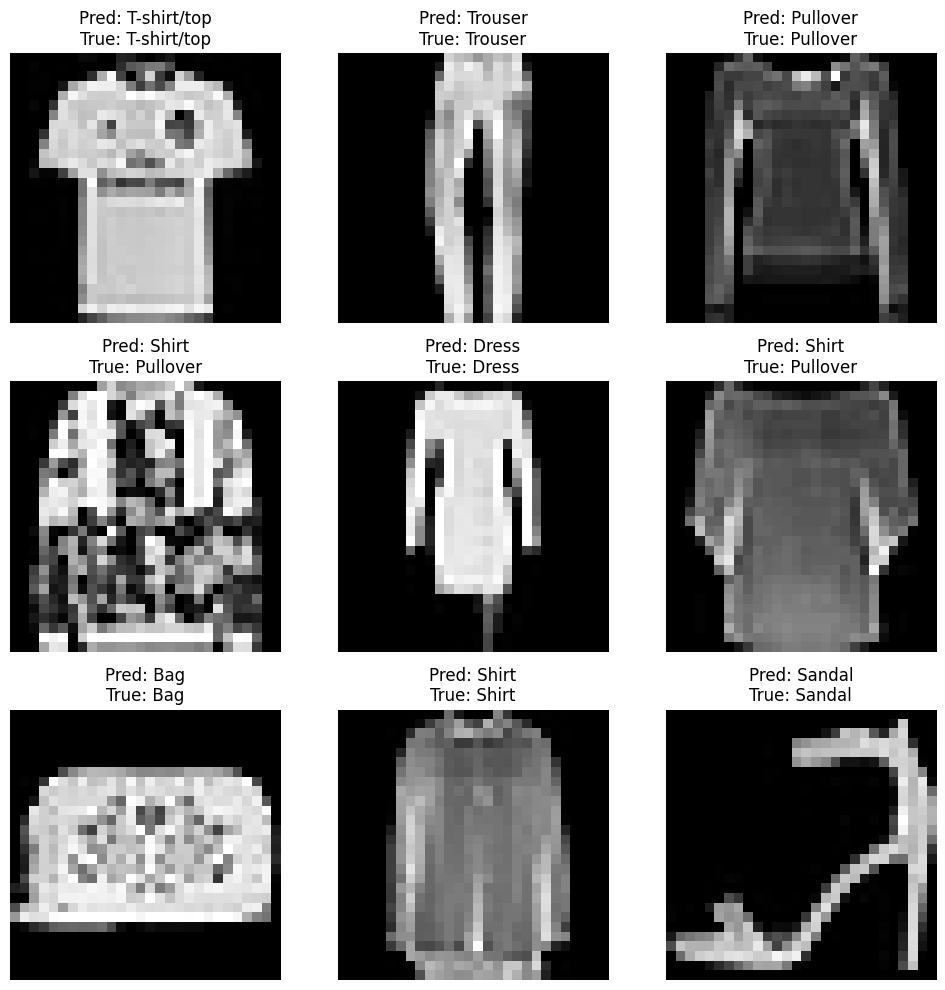

In [18]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()